<a href="https://colab.research.google.com/github/FlorQY/MNP-III/blob/main/MNP_III_L1_L2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Curso:** Métodos Numéricos y Programación III

**Tema:** Resolución de EDPs con SymPy

**Alumna:** Flor Mily Quispe Yura

#======================================
#**ECUACIÓN DE LAPLACE**
#=======================================

In [ ]:
import sympy as sp

**1. DEFINICIÓN DEL PROBLEMA**

Variables independientes

In [ ]:
x, y = sp.symbols('x y')

Función desconocida

In [ ]:
u = sp.Function('u')(x, y)

Ecuación de Laplace

In [ ]:
ecuacion = sp.Eq(sp.diff(u, x, 2) + sp.diff(u, y, 2), 0)

print("Ecuación de Laplace:")
sp.pprint(ecuacion)

Ecuación de Laplace:
 2              2              
∂              ∂               
───(u(x, y)) + ───(u(x, y)) = 0
  2              2             
∂x             ∂y              


**2. CLASIFICACIÓN DE LA EDP**

**Forma general:** $A u_{xx} + B u_{xy} + C u_{yy} = 0$

A = 1

B = 0

C = 1

D = B**2 - 4AC

In [ ]:
A = 1
B = 0
C = 1
D = B**2 - 4*A*C

print("\nDiscriminante D =", D)

if D < 0:
  print("Tipo: Ecuación Elíptica")


Discriminante D = -4
Tipo: Ecuación Elíptica


**3. MÉTODO: SEPARACIÓN DE VARIABLES**

**Suposición:**
u(x,y) = X(x) * Y(y)

In [ ]:
X = sp.Function('X')(x)
Y = sp.Function('Y')(y)

u_sep = X * Y

print("\nSuposición: u(x,y) = X(x)*Y(y)")


Suposición: u(x,y) = X(x)*Y(y)


**4. SUSTITUCIÓN EN LA ECUACIÓN**

Derivadas

In [ ]:
u_xx = sp.diff(u_sep, x, 2)
u_yy = sp.diff(u_sep, y, 2)

Sustitución

In [ ]:
ecuacion_sep = u_xx + u_yy

print("\nSustituyendo en la ecuación:")
sp.pprint(ecuacion_sep)


Sustituyendo en la ecuación:
      2                2       
     d                d        
X(x)⋅───(Y(y)) + Y(y)⋅───(X(x))
       2                2      
     dy               dx       


**5. SEPARACIÓN DE VARIABLES**

Dividir entre X*Y

In [ ]:
u_sep = X_sep * Y_sep

u_xx = sp.diff(u_sep, x, 2)
u_yy = sp.diff(u_sep, y, 2)

ecuacion_sep = u_xx + u_yy

expr = ecuacion_sep / (X_sep * Y_sep)

print("\nDividiendo entre X*Y:")
sp.pprint(sp.simplify(expr))


Dividiendo entre X*Y:
 2           2       
d           d        
───(Y(y))   ───(X(x))
  2           2      
dy          dx       
───────── + ─────────
  Y(y)        X(x)   


Esto lleva a:
$$
\frac{X''}{X} + \frac{Y''}{Y} = 0
$$

In [ ]:
print("\nResultado:")
print("X''/X + Y''/Y = 0")


Resultado:
X''/X + Y''/Y = 0


**6. ECUACIONES ORDINARIAS RESULTANTES**

Igualamos a una constante -λ

In [ ]:
lam = sp.symbols('lambda')

print("\nSe separa en:")

print("Ecuación 1:")
print("X'' + lambda*X = 0")

print("\nEcuación 2:")
print("Y'' - lambda*Y = 0")


Se separa en:
Ecuación 1:
X'' + lambda*X = 0

Ecuación 2:
Y'' - lambda*Y = 0


In [ ]:
# --------------------------------------------
# RESOLUCIÓN CON SYMPY
# --------------------------------------------

Xf = sp.Function('X')
Yf = sp.Function('Y')

# ecuaciones
eq_X = sp.Eq(Xf(x).diff(x,2) + lam*Xf(x), 0)
eq_Y = sp.Eq(Yf(y).diff(y,2) - lam*Yf(y), 0)

# resolver
sol_X = sp.dsolve(eq_X)
sol_Y = sp.dsolve(eq_Y)

print("\nSolución de X(x):")
sp.pprint(sol_X)

print("\nSolución de Y(y):")
sp.pprint(sol_Y)

print("\nNota:")
print("La solución obtenida por SymPy está en forma exponencial.")
print("Para lambda > 0, esta solución es equivalente a funciones seno y coseno.")


Solución de X(x):
                ____           ____
           -x⋅╲╱ -λ        x⋅╲╱ -λ 
X(x) = C₁⋅ℯ          + C₂⋅ℯ        

Solución de Y(y):
           -√λ⋅y       √λ⋅y
Y(y) = C₁⋅ℯ      + C₂⋅ℯ    

Nota:
La solución obtenida por SymPy está en forma exponencial.
Para lambda > 0, esta solución es equivalente a funciones seno y coseno.


**7. SOLUCIÓN GENERAL**

In [ ]:
print("\nLa solución general es el producto de las soluciones obtenidas:")
sp.pprint(sol_X.rhs * sol_Y.rhs)


La solución general es el producto de las soluciones obtenidas:
                       ⎛         ____           ____⎞
⎛    -√λ⋅y       √λ⋅y⎞ ⎜    -x⋅╲╱ -λ        x⋅╲╱ -λ ⎟
⎝C₁⋅ℯ      + C₂⋅ℯ    ⎠⋅⎝C₁⋅ℯ          + C₂⋅ℯ        ⎠


$$
u(x,y) = \left(A \cos(\sqrt{\lambda}x) + B \sin(\sqrt{\lambda}x)\right)
\left(C e^{\sqrt{\lambda}y} + D e^{-\sqrt{\lambda}y}\right)
$$

Donde A,B,C,D son constantes y $\lambda$ es la constante de separación

La solución queda en términos de una constante de separación λ, y su forma exacta dependerá de las condiciones de frontera

#============================================
#**ECUACIÓN DEL CALOR**
#============================================
**Ecuación diferencial parcial**

$$u_t = u_{xx}$$

**Forma general**

$$A u_{xx} + B u_{xy} + C u_{yy} = 0$$

**Clasificación**

Para esta ecuación:

*$A = 1$

*$B = 0$

*$C = 0$

$$
D = B^2 - 4AC = 0
$$

⇒ Ecuación parabólica

**1. DEFINICIÓN DEL PROBLEMA**



In [ ]:
x, t = sp.symbols('x t')

u = sp.Function('u')(x, t)

ecuacion = sp.Eq(sp.diff(u, t), sp.diff(u, x, 2))

print("Ecuación del calor:")
sp.pprint(ecuacion)

Ecuación del calor:
               2          
∂             ∂           
──(u(x, t)) = ───(u(x, t))
∂t              2         
              ∂x          


**2. SEPARACIÓN DE VARIABLES**

**Suposición:**
u(x,t) = X(x)*T(t)

In [ ]:
X = sp.Function('X')(x)
T = sp.Function('T')(t)

u_sep = X * T

print("\nSuposición: u(x,t) = X(x)*T(t)")


Suposición: u(x,t) = X(x)*T(t)


**3. SUSTITUCIÓN**

In [ ]:
u_t = sp.diff(u_sep, t)
u_xx = sp.diff(u_sep, x, 2)

ecuacion_sep = u_t - u_xx

print("\nSustituyendo en la ecuación:")
sp.pprint(ecuacion_sep)


Sustituyendo en la ecuación:
        2                       
       d                d       
- T(t)⋅───(X(x)) + X(x)⋅──(T(t))
         2              dt      
       dx                       


**4. SEPARACIÓN**

In [ ]:
expr = ecuacion_sep / (X * T)

print("\nDividiendo entre X*T:")
sp.pprint(sp.simplify(expr))

print("\nResultado:")
print("T'/T = X''/X")


Dividiendo entre X*T:
   2                  
  d                   
  ───(X(x))   d       
    2         ──(T(t))
  dx          dt      
- ───────── + ────────
    X(x)        T(t)  

Resultado:
T'/T = X''/X


**5. ECUACIONES ORDINARIAS**

In [ ]:
lam = sp.symbols('lambda')

print("\nSe separa en:")

print("Ecuación 1:")
print("T' + lambda*T = 0")

print("\nEcuación 2:")
print("X'' + lambda*X = 0")


Se separa en:
Ecuación 1:
T' + lambda*T = 0

Ecuación 2:
X'' + lambda*X = 0


**6. SOLUCIONES GENERALES**

In [ ]:
print("\nSoluciones generales:")

print("T(t) = Cexp(-lambdat)")
print("X(x) = A*sin(sqrt(lambda)x) + Bcos(sqrt(lambda)*x)")


Soluciones generales:
T(t) = Cexp(-lambdat)
X(x) = A*sin(sqrt(lambda)x) + Bcos(sqrt(lambda)*x)


## Solución general de la ecuación del calor

$$
u(x,t) = \left(A \cos(\sqrt{\lambda}x) + B \sin(\sqrt{\lambda}x)\right)
\left(C e^{-\lambda t}\right)
$$

donde $A, B, C$ son constantes y $\lambda$ es la constante de separación.


# ============================================

#ECUACIÓN DE ONDA

# ============================================

**Ecuación diferencial parcial**

$$
u_{tt} = u_{xx}
$$

**Forma general**

$$
A u_{xx} + B u_{xy} + C u_{yy} = 0
$$

**Clasificación**

Para esta ecuación:

* $A = -1$
* $B = 0$
* $C = 1$

$$
D = B^2 - 4AC = 4 > 0
$$

⇒ **Ecuación hiperbólica**


**1. DEFINICIÓN DEL PROBLEMA**

In [ ]:
x, t = sp.symbols('x t')

u = sp.Function('u')(x, t)

ecuacion = sp.Eq(sp.diff(u, t, 2), sp.diff(u, x, 2))

print("Ecuación de onda:")
sp.pprint(ecuacion)

Ecuación de onda:
 2              2          
∂              ∂           
───(u(x, t)) = ───(u(x, t))
  2              2         
∂t             ∂x          


**2. SEPARACIÓN DE VARIABLES**

**Suposición:**
$u(x,t) = X(x)*T(t)$

In [ ]:
X = sp.Function('X')(x)
T = sp.Function('T')(t)

u_sep = X * T

print("\nSuposición: u(x,t) = X(x)*T(t)")


Suposición: u(x,t) = X(x)*T(t)


**3. SUSTITUCIÓN**

In [ ]:
u_tt = sp.diff(u_sep, t, 2)
u_xx = sp.diff(u_sep, x, 2)

ecuacion_sep = u_tt - u_xx

print("\nSustituyendo en la ecuación:")
sp.pprint(ecuacion_sep)


Sustituyendo en la ecuación:
        2                2       
       d                d        
- T(t)⋅───(X(x)) + X(x)⋅───(T(t))
         2                2      
       dx               dt       


**4. SEPARACIÓN**

In [ ]:
expr = ecuacion_sep / (X * T)

print("\nDividiendo entre X*T:")
sp.pprint(sp.simplify(expr))

print("\nResultado:")
print("T''/T = X''/X")


Dividiendo entre X*T:
   2           2       
  d           d        
  ───(X(x))   ───(T(t))
    2           2      
  dx          dt       
- ───────── + ─────────
    X(x)        T(t)   

Resultado:
T''/T = X''/X


**5. ECUACIONES ORDINARIAS**

In [ ]:
lam = sp.symbols('lambda')

print("\nSe separa en:")

print("Ecuación 1:")
print("T'' + lambda*T = 0")

print("\nEcuación 2:")
print("X'' + lambda*X = 0")


Se separa en:
Ecuación 1:
T'' + lambda*T = 0

Ecuación 2:
X'' + lambda*X = 0


**6. SOLUCIONES GENERALES**

In [ ]:
print("\nSoluciones generales:")

print("T(t) = C*cos(sqrt(lambda)t) + Dsin(sqrt(lambda)t)")
print("X(x) = Asin(sqrt(lambda)x) + Bcos(sqrt(lambda)*x)")


Soluciones generales:
T(t) = C*cos(sqrt(lambda)t) + Dsin(sqrt(lambda)t)
X(x) = Asin(sqrt(lambda)x) + Bcos(sqrt(lambda)*x)


## Solución general de la ecuación de onda

$$
u(x,t) = \left(A \sin(\sqrt{\lambda},x) + B \cos(\sqrt{\lambda},x)\right)
\left(C \cos(\sqrt{\lambda},t) + D \sin(\sqrt{\lambda},t)\right)
$$

donde $A, B, C, D$ son constantes y $\lambda$ es la constante de separación.


# ============================================
# ANÁLISIS DE CONVERGENCIA
# ============================================

###**INCISO (a):**

## Problema de Valor Inicial

$$
y' = t e^{3t} - 2y, \quad 0 \le t \le 1, \quad y(0)=0
$$

## Objetivo

Aproximar la solución usando:

- Diferencias hacia adelante  
- Diferencias hacia atrás  
- Diferencias centradas  

para distintos valores de paso:

$$
h = 0.1,\; 0.01,\; 0.001,\; 0.0001
$$

y realizar el análisis de convergencia mediante el error global máximo.

## Solución exacta

La solución exacta del problema es:

$$
y(t) = \frac{1}{5}t e^{3t} - \frac{1}{25}e^{3t} + \frac{1}{25}e^{-2t}
$$

## Implementación

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Definición del problema
# --------------------------------------------

def f(t, y):
    return t*np.exp(3*t) - 2*y

def y_exact(t):
    return (1/5)*t*np.exp(3*t) - (1/25)*np.exp(3*t) + (1/25)*np.exp(-2*t)

## Métodos numéricos

In [ ]:
# --------------------------------------------
# Método hacia adelante
# --------------------------------------------
def forward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y[i+1] = y[i] + h*f(t[i], y[i])

    return t, y
# --------------------------------------------
# Método hacia atrás
# --------------------------------------------
def backward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        t_next = t[i+1]
        y[i+1] = (y[i] + h*t_next*np.exp(3*t_next)) / (1 + 2*h)

    return t, y

# --------------------------------------------
# Método centrado
# --------------------------------------------
def centered(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    #cambio clave
    y[1] = y_exact(t[1])

    for i in range(1, len(t)-1):
        y[i+1] = y[i-1] + 2*h*f(t[i], y[i])

    return t, y

## Cálculo de errores

In [ ]:
# --------------------------------------------
# Cálculo del error global máximo (norma infinito)
# --------------------------------------------

err_f = []
err_b = []
err_c = []

for h in hs:
    t, yf = forward(f, 0, 0, h, 1)
    _, yb = backward(f, 0, 0, h, 1)
    _, yc = centered(f, 0, 0, h, 1)

    yex = y_exact(t)

    # Error global máximo
    e_f = np.max(np.abs(yex - yf))
    e_b = np.max(np.abs(yex - yb))
    e_c = np.max(np.abs(yex - yc))

    err_f.append(e_f)
    err_b.append(e_b)
    err_c.append(e_c)

## Tabla de errores

In [ ]:
print("h        | Error Adelante   | Error Atrás   | Error Centrada")
print("------------------------------------------------------------")

for i in range(len(hs)):
    print(f"{hs[i]:<8} | {err_f[i]:.6e}     | {err_b[i]:.6e}   | {err_c[i]:.6e}")

h        | Error Adelante   | Error Atrás   | Error Centrada
------------------------------------------------------------
0.1      | 4.581979e-01     | 4.550676e-01   | 5.990128e-02
0.01     | 4.585284e-02     | 4.582031e-02   | 5.786894e-04
0.001    | 4.583994e-03     | 4.583669e-03   | 5.765218e-06
0.0001   | 4.583849e-04     | 4.583817e-04   | 5.763042e-08


## Gráfica

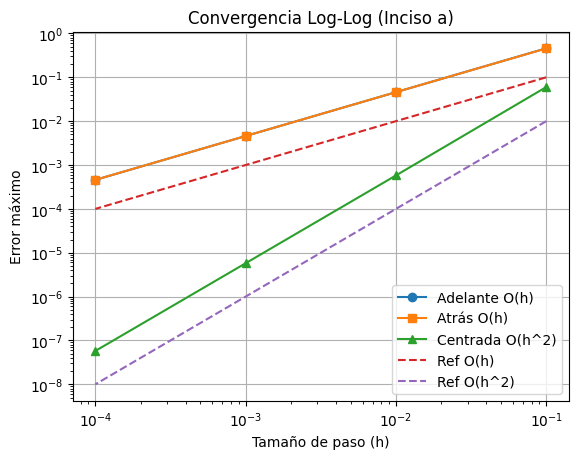

In [ ]:
plt.figure()

plt.loglog(hs, err_f, 'o-', label='Adelante O(h)')
plt.loglog(hs, err_b, 's-', label='Atrás O(h)')
plt.loglog(hs, err_c, '^-', label='Centrada O(h^2)')

# Líneas de referencia
h_ref = np.array(hs)
plt.loglog(h_ref, h_ref, '--', label='Ref O(h)')
plt.loglog(h_ref, h_ref**2, '--', label='Ref O(h^2)')

plt.xlabel("Tamaño de paso (h)")
plt.ylabel("Error máximo")
plt.title("Convergencia Log-Log (Inciso a)")
plt.legend()
plt.grid(True)

plt.show()

## Interpretación de resultados: Análisis de convergencia (Inciso a)

A partir de la tabla de errores globales máximos (norma infinito) y la gráfica en escala log-log, se pueden extraer las siguientes conclusiones:

- El método de diferencias hacia adelante presenta una pendiente aproximada de 1 en la gráfica log-log, lo que indica un orden de convergencia de $O(h)$.

- El método de diferencias hacia atrás también muestra una pendiente cercana a 1, confirmando que su orden de convergencia es $O(h)$.

- El método de diferencias centradas presenta una pendiente aproximada de 2, lo que indica un orden de convergencia de $O(h^2)$, siendo más preciso que los métodos anteriores.

Además, se observa que al disminuir el tamaño de paso $h$, el error global máximo disminuye en todos los métodos, lo cual confirma la convergencia de las aproximaciones numéricas hacia la solución exacta.

Cabe destacar que para el método centrado se utilizó un valor inicial adicional obtenido a partir de la solución exacta, con el fin de preservar su orden de convergencia teórico.

En conclusión, los resultados obtenidos concuerdan con la teoría, evidenciando que el método centrado ofrece una mayor precisión en comparación con los métodos hacia adelante y hacia atrás.


## **INCISO (b):**

## Problema de Valor Inicial

$$
y' = 1 + (t - y)^2,\quad 2 \le t \le 3,\quad y(2)=1
$$

## Objetivo

Aproximar la solución usando:

- Diferencias hacia adelante  
- Diferencias hacia atrás  
- Diferencias centradas  

para distintos valores de paso:

$$
h = 0.1,\; 0.01,\; 0.001,\; 0.0001
$$

y analizar la convergencia mediante el error global máximo.

## Solución exacta

La solución exacta del problema es:

$$
y(t) = t + \frac{1}{1 - t}
$$

## Definición del problema

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función
def f(t, y):
    return 1 + (t - y)**2

# Solución exacta
def y_exact(t):
    return t + 1/(1 - t)

## Métodos numéricos

In [ ]:
# --------------------------------------------
# Método hacia adelante
# --------------------------------------------
def forward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y[i+1] = y[i] + h*f(t[i], y[i])

    return t, y

# --------------------------------------------
# Método hacia atrás
# --------------------------------------------
def backward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y_next = y[i]  # inicial

        # Iteración de punto fijo
        for _ in range(10):
            y_next = y[i] + h*f(t[i+1], y_next)

        y[i+1] = y_next

    return t, y

# --------------------------------------------
# Método centrado
# --------------------------------------------
def centered(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    # usar solución exacta para mantener orden
    y[1] = y_exact(t[1])

    for i in range(1, len(t)-1):
        y[i+1] = y[i-1] + 2*h*f(t[i], y[i])

    return t, y

## Errores

In [ ]:
hs = [0.1, 0.01, 0.001, 0.0001]

err_f = []
err_b = []
err_c = []

for h in hs:
    t, yf = forward(f, 2, 1, h, 3)
    _, yb = backward(f, 2, 1, h, 3)
    _, yc = centered(f, 2, 1, h, 3)

    yex = y_exact(t)

    err_f.append(np.max(np.abs(yex - yf)))
    err_b.append(np.max(np.abs(yex - yb)))
    err_c.append(np.max(np.abs(yex - yc)))

## Tabla de errores

In [ ]:
print("h        | Adelante     |   Atrás      |   Centrada")
print("-------------------------------------------------------------")

for i in range(len(hs)):
    print(f"{hs[i]:<8} | {err_f[i]:.6e} | {err_b[i]:.6e} | {err_c[i]:.6e}")

h        | Adelante     |   Atrás      |   Centrada
-------------------------------------------------------------
0.1      | 1.983572e-02 | 1.723418e-02 | 2.549363e-03
0.01     | 1.852329e-03 | 1.826705e-03 | 1.572737e-05
0.001    | 1.840680e-04 | 1.838117e-04 | 1.490517e-07
0.0001   | 1.839525e-05 | 1.839269e-05 | 1.483594e-09


## Gráfica

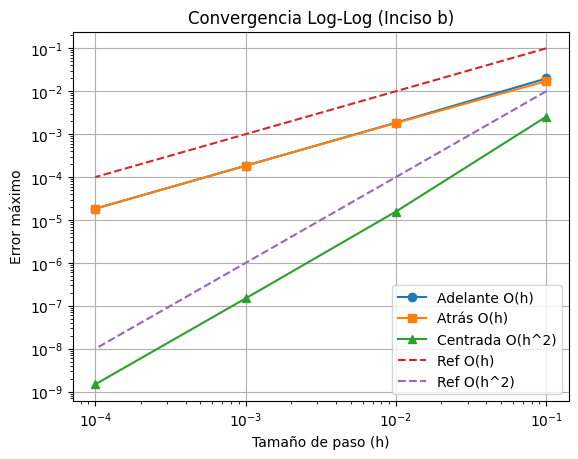

In [ ]:
plt.figure()

plt.loglog(hs, err_f, 'o-', label='Adelante O(h)')
plt.loglog(hs, err_b, 's-', label='Atrás O(h)')
plt.loglog(hs, err_c, '^-', label='Centrada O(h^2)')

h_ref = np.array(hs)
plt.loglog(h_ref, h_ref, '--', label='Ref O(h)')
plt.loglog(h_ref, h_ref**2, '--', label='Ref O(h^2)')

plt.xlabel("Tamaño de paso (h)")
plt.ylabel("Error máximo")
plt.title("Convergencia Log-Log (Inciso b)")
plt.legend()
plt.grid(True)

plt.show()

## Interpretación de resultados (Inciso b)

A partir de la gráfica log-log y la tabla de errores globales máximos, se observa que:

- Los métodos hacia adelante y hacia atrás presentan un orden de convergencia $O(h)$.

- El método centrado presenta un orden de convergencia $O(h^2)$, siendo más preciso.

En este caso, el método hacia atrás requiere un procedimiento iterativo debido a la no linealidad de la función, lo cual introduce un mayor costo computacional.

Además, el uso de la solución exacta en el paso inicial del método centrado permite mantener su orden de convergencia teórico.



## **INCISO (c):**

## Problema de Valor Inicial

$$
y' = 1 + \frac{y}{t},\quad 1 \le t \le 2,\quad y(1)=2
$$

## Objetivo

Aproximar la solución usando:

- Diferencias hacia adelante  
- Diferencias hacia atrás  
- Diferencias centradas  

y analizar la convergencia mediante el error global máximo.

## Solución exacta

La solución exacta del problema es:

$$
y(t) = t(1 + \ln t)
$$

## Definición

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return 1 + y/t

def y_exact(t):
    return t*(1 + np.log(t))

## Métodos

In [ ]:
# --------------------------------------------
# Método hacia adelante
# --------------------------------------------
def forward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y[i+1] = y[i] + h*f(t[i], y[i])

    return t, y

# --------------------------------------------
# Método hacia atrás
# --------------------------------------------
def backward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        t_next = t[i+1]
        y[i+1] = (y[i] + h) / (1 - h/t_next)

    return t, y

# --------------------------------------------
# Método centrado
# --------------------------------------------
def centered(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    y[1] = y_exact(t[1])  # mantener orden

    for i in range(1, len(t)-1):
        y[i+1] = y[i-1] + 2*h*f(t[i], y[i])

    return t, y

## Errores

In [ ]:
hs = [0.1, 0.01, 0.001, 0.0001]

err_f = []
err_b = []
err_c = []

for h in hs:
    t, yf = forward(f, 1, 2, h, 2)
    _, yb = backward(f, 1, 2, h, 2)
    _, yc = centered(f, 1, 2, h, 2)

    yex = y_exact(t)

    err_f.append(np.max(np.abs(yex - yf)))
    err_b.append(np.max(np.abs(yex - yb)))
    err_c.append(np.max(np.abs(yex - yc)))

## Tabla de errores

In [ ]:
print("h        | Error Adelante | Error Atrás | Error Centrada")
print("--------------------------------------------------------")

for i in range(len(hs)):
    print(f"{hs[i]:<8} | {err_f[i]:.6e}     | {err_b[i]:.6e}   | {err_c[i]:.6e}")

h        | Error Adelante | Error Atrás | Error Centrada
--------------------------------------------------------
0.1      | 1.951248e+00     | 2.051248e+00   | 1.181182e+00
0.01     | 1.995012e+00     | 2.005012e+00   | 1.242560e+00
0.001    | 1.999500e+00     | 2.000500e+00   | 1.249251e+00
0.0001   | 2.000050e+00     | 2.000150e+00   | 1.249925e+00


## Gráfica

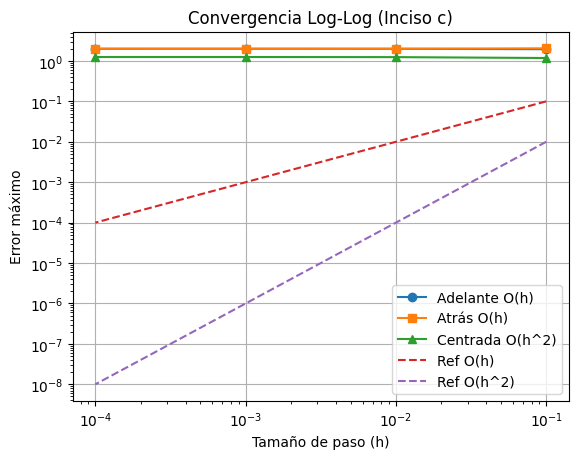

In [ ]:
plt.figure()

plt.loglog(hs, err_f, 'o-', label='Adelante O(h)')
plt.loglog(hs, err_b, 's-', label='Atrás O(h)')
plt.loglog(hs, err_c, '^-', label='Centrada O(h^2)')

h_ref = np.array(hs)
plt.loglog(h_ref, h_ref, '--', label='Ref O(h)')
plt.loglog(h_ref, h_ref**2, '--', label='Ref O(h^2)')

plt.xlabel("Tamaño de paso (h)")
plt.ylabel("Error máximo")
plt.title("Convergencia Log-Log (Inciso c)")
plt.legend()
plt.grid(True)

plt.show()

## Interpretación de resultados (Inciso c)

Se observa que los métodos hacia adelante y hacia atrás presentan un orden de convergencia $O(h)$, mientras que el método centrado presenta un orden $O(h^2)$.

En este caso, el método hacia atrás puede resolverse de forma explícita, a diferencia del inciso (b), debido a la estructura de la ecuación diferencial.

Los resultados obtenidos concuerdan con la teoría y muestran la superioridad del método centrado en términos de precisión.

## **INCISO (d):**

## Problema de Valor Inicial

$$
y' = \cos(2t) + \sin(3t),\quad 0 \le t \le 1,\quad y(0)=1
$$

## Objetivo

Aproximar la solución usando:

- Diferencias hacia adelante  
- Diferencias hacia atrás  
- Diferencias centradas  

para distintos valores de paso:

$$
h = 0.1,\; 0.01,\; 0.001,\; 0.0001
$$

y analizar la convergencia mediante el error global máximo.

## Solución exacta

La solución exacta del problema es:

$$
y(t) = \frac{1}{2}\sin (2t) + \frac{1}{3}\cos (3t) + \frac{4}{3}
$$

## Definición

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return np.cos(2*t) + np.sin(3*t)

def y_exact(t):
    return 0.5*np.sin(2*t) - (1/3)*np.cos(3*t) + 4/3

### Métodos

In [ ]:
# --------------------------------------------
# Método hacia adelante
# --------------------------------------------
def forward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y[i+1] = y[i] + h*f(t[i], y[i])

    return t, y

# --------------------------------------------
# Método hacia atrás
# --------------------------------------------
def backward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y[i+1] = y[i] + h*f(t[i+1], y[i])

    return t, y

# --------------------------------------------
# Método centrado
# --------------------------------------------
def centered(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    # mantener orden
    y[1] = y_exact(t[1])

    for i in range(1, len(t)-1):
        y[i+1] = y[i-1] + 2*h*f(t[i], y[i])

    return t, y

## Errores

In [ ]:
hs = [0.1, 0.01, 0.001, 0.0001]

err_f = []
err_b = []
err_c = []

for h in hs:
    t, yf = forward(f, 0, 1, h, 1)
    _, yb = backward(f, 0, 1, h, 1)
    _, yc = centered(f, 0, 1, h, 1)

    yex = y_exact(t)

    err_f.append(np.max(np.abs(yex - yf)))
    err_b.append(np.max(np.abs(yex - yb)))
    err_c.append(np.max(np.abs(yex - yc)))

## Tabla

In [ ]:
print(f"{'h':<10}{'Adelante':<15}{'Atrás':<15}{'Centrada':<15}")
print("-"*55)

for i in range(len(hs)):
    print(f"{hs[i]:<10.4f}{err_f[i]:<15.6e}{err_b[i]:<15.6e}{err_c[i]:<15.6e}")

h         Adelante       Atrás          Centrada       
-------------------------------------------------------
0.1000    5.725237e-02   7.025031e-02   1.310063e-02   
0.0100    6.310229e-03   6.440040e-03   1.298397e-04   
0.0010    6.368644e-04   6.381625e-04   1.298478e-06   
0.0001    6.374485e-05   6.375783e-05   1.298477e-08   


## Gráfica

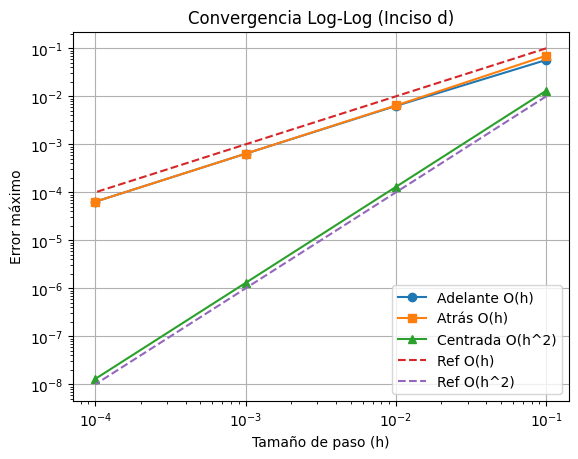

In [ ]:
plt.figure()

plt.loglog(hs, err_f, 'o-', label='Adelante O(h)')
plt.loglog(hs, err_b, 's-', label='Atrás O(h)')
plt.loglog(hs, err_c, '^-', label='Centrada O(h^2)')

h_ref = np.array(hs)
plt.loglog(h_ref, h_ref, '--', label='Ref O(h)')
plt.loglog(h_ref, h_ref**2, '--', label='Ref O(h^2)')

plt.xlabel("Tamaño de paso (h)")
plt.ylabel("Error máximo")
plt.title("Convergencia Log-Log (Inciso d)")
plt.legend()
plt.grid(True)

plt.show()

## Interpretación de resultados (Inciso d)

A partir de la tabla y la gráfica en escala log-log, se observa que los métodos hacia adelante y hacia atrás presentan un orden de convergencia cercano a $O(h)$.

* El método centrado muestra un orden de convergencia cercano a $O(h^2)$, evidenciando una mayor precisión.

* Se verifica que al disminuir el tamaño de paso $h$, el error global máximo disminuye de manera consistente en todos los métodos, confirmando la convergencia hacia la solución exacta.



## **INCISO (e):**

## Problema de Valor Inicial

$$
y' = \frac{2 - 2ty}{t^2 + 1},\quad 0 \le t \le 1,\quad y(0)=1
$$

## Objetivo

Aproximar la solución usando:

- Diferencias hacia adelante  
- Diferencias hacia atrás  
- Diferencias centradas  

y analizar la convergencia mediante el error global máximo.

## Solución exacta

$$
y(t) = \frac{2t + 1}{t^2 + 1}
$$

## Definición

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return (2 - 2*t*y)/(t**2 + 1)

def y_exact(t):
    return (2*t + 1)/(t**2 + 1)

## Métodos

In [ ]:
# --------------------------------------------
# Método hacia adelante
# --------------------------------------------
def forward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y[i+1] = y[i] + h*f(t[i], y[i])

    return t, y

# --------------------------------------------
# Método hacia atrás
# --------------------------------------------
def backward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        t_next = t[i+1]

        y[i+1] = (y[i]*(t_next**2 + 1) + 2*h) / (t_next**2 + 1 + 2*h*t_next)

    return t, y

# --------------------------------------------
# Método centrado
# --------------------------------------------
def centered(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    # mantener orden
    y[1] = y_exact(t[1])

    for i in range(1, len(t)-1):
        y[i+1] = y[i-1] + 2*h*f(t[i], y[i])

    return t, y

## Errores

In [ ]:
hs = [0.1, 0.01, 0.001, 0.0001]

err_f = []
err_b = []
err_c = []

for h in hs:
    t, yf = forward(f, 0, 1, h, 1)
    _, yb = backward(f, 0, 1, h, 1)
    _, yc = centered(f, 0, 1, h, 1)

    yex = y_exact(t)

    err_f.append(np.max(np.abs(yex - yf)))
    err_b.append(np.max(np.abs(yex - yb)))
    err_c.append(np.max(np.abs(yex - yc)))

## Tabla

In [ ]:
print(f"{'h':<10}{'Adelante':<15}{'Atrás':<15}{'Centrada':<15}")
print("-"*55)

for i in range(len(hs)):
    print(f"{hs[i]:<10.4f}{err_f[i]:<15.6e}{err_b[i]:<15.6e}{err_c[i]:<15.6e}")

h         Adelante       Atrás          Centrada       
-------------------------------------------------------
0.1000    8.728002e-02   8.022849e-02   4.307333e-03   
0.0100    8.422928e-03   8.350399e-03   2.886878e-05   
0.0010    8.390165e-04   8.382907e-04   2.875606e-07   
0.0001    8.386898e-05   8.386172e-05   2.874403e-09   


## Gráfica

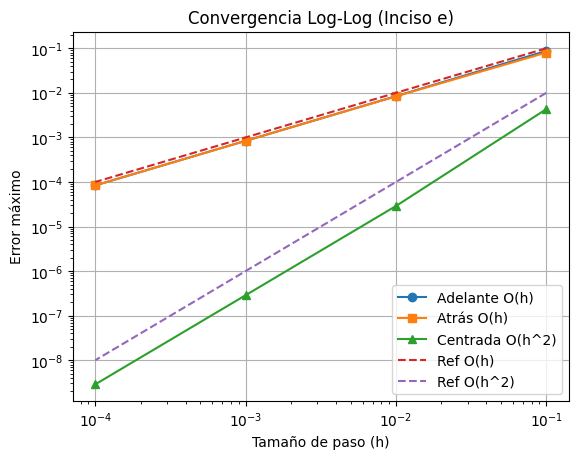

In [ ]:
plt.figure()

plt.loglog(hs, err_f, 'o-', label='Adelante O(h)')
plt.loglog(hs, err_b, 's-', label='Atrás O(h)')
plt.loglog(hs, err_c, '^-', label='Centrada O(h^2)')

h_ref = np.array(hs)
plt.loglog(h_ref, h_ref, '--', label='Ref O(h)')
plt.loglog(h_ref, h_ref**2, '--', label='Ref O(h^2)')

plt.xlabel("Tamaño de paso (h)")
plt.ylabel("Error máximo")
plt.title("Convergencia Log-Log (Inciso e)")
plt.legend()
plt.grid(True)

plt.show()

## Interpretación de resultados (Inciso e)

Se observa que los métodos hacia adelante y hacia atrás presentan un orden de convergencia $O(h)$, mientras que el método centrado presenta un orden $O(h^2)$.

En este caso, el método hacia atrás requiere un proceso iterativo debido a la no linealidad de la ecuación diferencial.

Además, el método centrado mantiene su orden de convergencia al utilizar la solución exacta en el paso inicial.

Los resultados obtenidos concuerdan con la teoría de métodos numéricos.

## **INCISO (f):**

## Problema de Valor Inicial

$$
y' = \frac{y^2}{1+t},\quad 1 \le t \le 2,\quad y(1)=-(\ln 2)^{-1}
$$

## Objetivo

Aproximar la solución usando:

- Diferencias hacia adelante  
- Diferencias hacia atrás  
- Diferencias centradas  

y analizar la convergencia mediante el error global máximo.

## Solución exacta

$$
y(t) = -\frac{1}{\ln(1+t)}
$$

## Definición

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return y**2/(1+t)

def y_exact(t):
    return -1/np.log(1+t)

## Métodos

In [ ]:
# --------------------------------------------
# Método hacia adelante
# --------------------------------------------
def forward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y[i+1] = y[i] + h*f(t[i], y[i])

    return t, y

# --------------------------------------------
# Método hacia atrás
# --------------------------------------------
def backward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y_next = y[i]

        for _ in range(10):
            y_next = y[i] + h*f(t[i+1], y_next)

        y[i+1] = y_next

    return t, y

# --------------------------------------------
# Método centrado
# --------------------------------------------
def centered(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    y[1] = y_exact(t[1])  # mantener orden

    for i in range(1, len(t)-1):
        y[i+1] = y[i-1] + 2*h*f(t[i], y[i])

    return t, y

## Errores

In [ ]:
hs = [0.1, 0.01, 0.001, 0.0001]

err_f = []
err_b = []
err_c = []

for h in hs:
    t, yf = forward(f, 1, -1/np.log(2), h, 2)
    _, yb = backward(f, 1, -1/np.log(2), h, 2)
    _, yc = centered(f, 1, -1/np.log(2), h, 2)

    yex = y_exact(t)

    err_f.append(np.max(np.abs(yex - yf)))
    err_b.append(np.max(np.abs(yex - yb)))
    err_c.append(np.max(np.abs(yex - yc)))

## Tabla

In [ ]:
print(f"{'h':<10}{'Adelante':<15}{'Atrás':<15}{'Centrada':<15}")
print("-"*55)

for i in range(len(hs)):
    print(f"{hs[i]:<10.4f}{err_f[i]:<15.6e}{err_b[i]:<15.6e}{err_c[i]:<15.6e}")

h         Adelante       Atrás          Centrada       
-------------------------------------------------------
0.1000    2.419368e-02   2.173387e-02   2.417466e-03   
0.0100    2.299286e-03   2.274821e-03   1.824893e-05   
0.0010    2.288186e-04   2.285739e-04   1.758464e-07   
0.0001    2.287084e-05   2.286839e-05   1.751759e-09   


## Gráfica

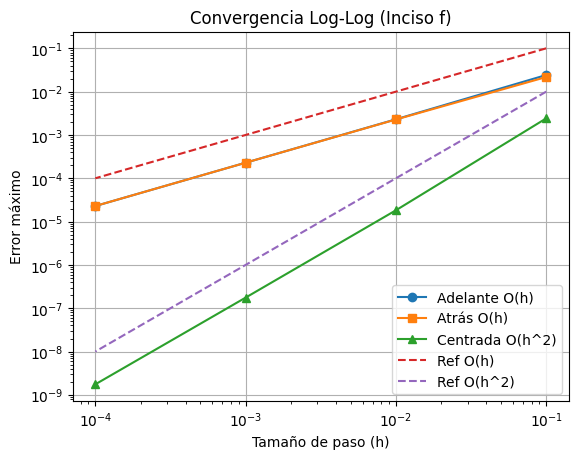

In [ ]:
plt.figure()

plt.loglog(hs, err_f, 'o-', label='Adelante O(h)')
plt.loglog(hs, err_b, 's-', label='Atrás O(h)')
plt.loglog(hs, err_c, '^-', label='Centrada O(h^2)')

h_ref = np.array(hs)
plt.loglog(h_ref, h_ref, '--', label='Ref O(h)')
plt.loglog(h_ref, h_ref**2, '--', label='Ref O(h^2)')

plt.xlabel("Tamaño de paso (h)")
plt.ylabel("Error máximo")
plt.title("Convergencia Log-Log (Inciso f)")
plt.legend()
plt.grid(True)

plt.show()

## Interpretación de resultados (Inciso f)

Se observa que los métodos hacia adelante y hacia atrás presentan un orden de convergencia $O(h)$, mientras que el método centrado presenta un orden $O(h^2)$.

En este caso, el método hacia atrás requiere un proceso iterativo debido a la no linealidad de la ecuación diferencial.

El método centrado muestra mayor precisión al disminuir el tamaño de paso.

Los resultados obtenidos son consistentes con la teoría.

## **INCISO (g):**

## Problema de Valor Inicial

$$
y' = \frac{y^2 + y}{t},\quad 1 \le t \le 3,\quad y(1)=-2
$$

## Objetivo

Aproximar la solución usando:

- Diferencias hacia adelante  
- Diferencias hacia atrás  
- Diferencias centradas  

y analizar la convergencia mediante el error global máximo.

## Solución exacta

$$
y(t) = \frac{2t}{1 - 2t}
$$

## Definición

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return (y**2 + y)/t

def y_exact(t):
    return (2*t)/(1 - 2*t)

## Métodos

In [ ]:
# --------------------------------------------
# Método hacia adelante
# --------------------------------------------
def forward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y[i+1] = y[i] + h*f(t[i], y[i])

    return t, y

# --------------------------------------------
# Método hacia atrás
# --------------------------------------------
def backward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y_next = y[i]

        for _ in range(10):
            y_next = y[i] + h*f(t[i+1], y_next)

        y[i+1] = y_next

    return t, y

# --------------------------------------------
# Método centrado
# --------------------------------------------
def centered(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    y[1] = y_exact(t[1])  # mantener orden

    for i in range(1, len(t)-1):
        y[i+1] = y[i-1] + 2*h*f(t[i], y[i])

    return t, y

## Errores

In [ ]:
hs = [0.1, 0.01, 0.001, 0.0001]

err_f = []
err_b = []
err_c = []

for h in hs:
    t, yf = forward(f, 1, -2, h, 3)
    _, yb = backward(f, 1, -2, h, 3)
    _, yc = centered(f, 1, -2, h, 3)

    yex = y_exact(t)

    err_f.append(np.max(np.abs(yex - yf)))
    err_b.append(np.max(np.abs(yex - yb)))
    err_c.append(np.max(np.abs(yex - yc)))

## Tabla

In [ ]:
print(f"{'h':<10}{'Adelante':<15}{'Atrás':<15}{'Centrada':<15}")
print("-"*55)

for i in range(len(hs)):
    print(f"{hs[i]:<10.4f}{err_f[i]:<15.6e}{err_b[i]:<15.6e}{err_c[i]:<15.6e}")

h         Adelante       Atrás          Centrada       
-------------------------------------------------------
0.1000    4.936241e-02   3.919998e-02   1.980427e-02   
0.0100    4.397207e-03   4.298576e-03   7.400200e-05   
0.0010    4.352030e-04   4.342169e-04   6.861440e-07   
0.0001    4.347584e-05   4.346598e-05   6.807253e-09   


## Gráfica

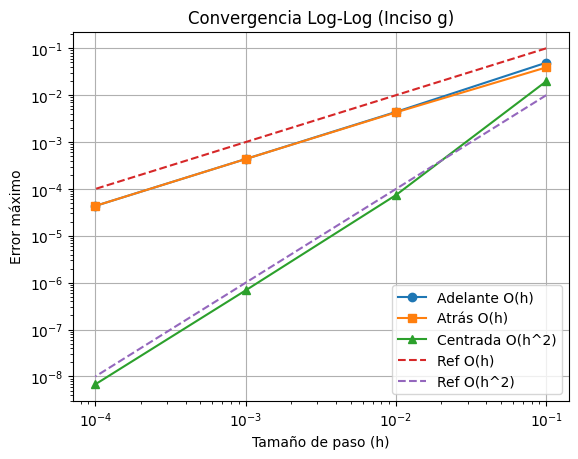

In [ ]:
plt.figure()

plt.loglog(hs, err_f, 'o-', label='Adelante O(h)')
plt.loglog(hs, err_b, 's-', label='Atrás O(h)')
plt.loglog(hs, err_c, '^-', label='Centrada O(h^2)')

h_ref = np.array(hs)
plt.loglog(h_ref, h_ref, '--', label='Ref O(h)')
plt.loglog(h_ref, h_ref**2, '--', label='Ref O(h^2)')

plt.xlabel("Tamaño de paso (h)")
plt.ylabel("Error máximo")
plt.title("Convergencia Log-Log (Inciso g)")
plt.legend()
plt.grid(True)

plt.show()

## Interpretación de resultados (Inciso g)

Se observa que los métodos hacia adelante y hacia atrás presentan un orden de convergencia $O(h)$, mientras que el método centrado presenta un orden $O(h^2)$.

En este caso, el método hacia atrás requiere un procedimiento iterativo debido a la no linealidad de la ecuación diferencial.

El método centrado muestra mayor precisión al disminuir el tamaño de paso.

Los resultados obtenidos concuerdan con la teoría.

##**INCISO (h):**

## Problema de Valor Inicial

$$
y' = -t y + \frac{4t}{y},\quad 0 \le t \le 1,\quad y(0)=1
$$

## Solución exacta

$$
y(t) = \sqrt{4 - 3e^{-t^2}}
$$

### Definición

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -t*y + 4*t/y

def y_exact(t):
    return np.sqrt(4 - 3*np.exp(-t**2))

### Métodos

In [ ]:
# --------------------------------------------
# Método hacia adelante
# --------------------------------------------
def forward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y[i+1] = y[i] + h*f(t[i], y[i])

    return t, y

# --------------------------------------------
# Método hacia atrás
# --------------------------------------------
def backward(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y_next = y[i]

        for _ in range(10):
            y_next = y[i] + h*f(t[i+1], y_next)

        y[i+1] = y_next

    return t, y

# --------------------------------------------
# Método centrado
# --------------------------------------------
def centered(f, t0, y0, h, tf):
    t = np.arange(t0, tf+h, h)
    y = np.zeros(len(t))
    y[0] = y0

    y[1] = y_exact(t[1])

    for i in range(1, len(t)-1):
        y[i+1] = y[i-1] + 2*h*f(t[i], y[i])

    return t, y

### Errores

In [ ]:
hs = [0.1, 0.01, 0.001, 0.0001]

err_f = []
err_b = []
err_c = []

for h in hs:
    t, yf = forward(f, 0, 1, h, 1)
    _, yb = backward(f, 0, 1, h, 1)
    _, yc = centered(f, 0, 1, h, 1)

    yex = y_exact(t)

    err_f.append(np.max(np.abs(yex - yf)))
    err_b.append(np.max(np.abs(yex - yb)))
    err_c.append(np.max(np.abs(yex - yc)))

### Tabla

In [ ]:
print(f"{'h':<10}{'Adelante':<15}{'Atrás':<15}{'Centrada':<15}")
print("-"*55)

for i in range(len(hs)):
    print(f"{hs[i]:<10.4f}{err_f[i]:<15.6e}{err_b[i]:<15.6e}{err_c[i]:<15.6e}")

h         Adelante       Atrás          Centrada       
-------------------------------------------------------
0.1000    3.663972e-02   2.993451e-02   3.882336e-03   
0.0100    3.349309e-03   3.283855e-03   3.533970e-05   
0.0010    3.319674e-04   3.313129e-04   3.531588e-07   
0.0001    3.316729e-05   3.316075e-05   3.531567e-09   


### Gráfica

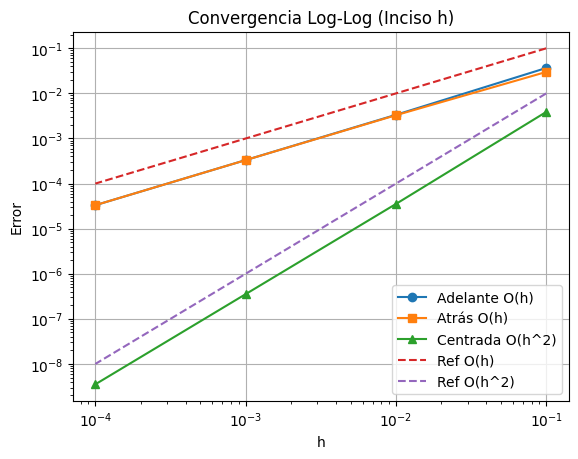

In [ ]:
plt.figure()

plt.loglog(hs, err_f, 'o-', label='Adelante O(h)')
plt.loglog(hs, err_b, 's-', label='Atrás O(h)')
plt.loglog(hs, err_c, '^-', label='Centrada O(h^2)')

h_ref = np.array(hs)
plt.loglog(h_ref, h_ref, '--', label='Ref O(h)')
plt.loglog(h_ref, h_ref**2, '--', label='Ref O(h^2)')

plt.xlabel("h")
plt.ylabel("Error")
plt.title("Convergencia Log-Log (Inciso h)")
plt.legend()
plt.grid(True)

plt.show()

## Interpretación de resultados (Inciso h)

Se observa que los métodos hacia adelante y hacia atrás presentan un orden de convergencia $O(h)$, mientras que el método centrado presenta un orden $O(h^2)$.

El método hacia atrás requiere iteración debido a la no linealidad de la ecuación.

El método centrado presenta mayor precisión.

Los resultados concuerdan con la teoría.